# Attempting a more efficient approach to the shortest paths problem.

The naive solution in `main.ipynb` calls `nx.algorithms.all_shortest_paths()` for each source-target pair - a total of `len(source) * len(target)` searches. This does not scale well, so to make this faster we want to limit the number of BFS searches. We also need to collect the interneurons, so our pipeline cannot give us path lengths alone.

This new approach leverages `numpy` arrays and `scipy` sparse matrices to efficiently perform BFS. Furthermore, the number of searches is minimized by choosing to search from the smaller neuron population, reversing edges if need be. A graph can be reversed by transposing its adjacency matrix (flipping rows & columns). Space is also minimized by mapping 18-digit IDs to IDs ranging from 0 to N-1, where N is the number of neurons referenced in the edge list.

In a total runtime of about 5 seconds, this code can perform all these analyses:

- ORNs (~3,000) <---> OviDNs (16)
- OviDNs <---> CAs (6)
- CAs <---> ORNs

## Step 1

Load edge list, map 18-digit root IDs to indices, and generate the adjacency matrix for the graph.

For the purposes of discovering absolute shortest paths, we ignore `syn_count` and treat the connectome as an unweighted graph, so the matrix only contains 1s and 0s. Edges are of course still directed.

In [1]:
import pandas as pd
import numpy as np
from scipy import sparse

edge_list = ( # edges are separated by neuropil, but we only care about total synapse count. group by edges and sum synapse counts
    pd.read_csv('data/connections_princeton.csv')
    .drop(columns=['nt_type']) # all empty
    .groupby(['pre_root_id', 'post_root_id'], as_index=False)['syn_count']
    .sum()
)

all_neurons = pd.concat([edge_list['pre_root_id'], edge_list['post_root_id']]).unique()
id_to_idx = {root_id: i for i, root_id in enumerate(all_neurons)}
# idx_to_id = {i: root_id for i, root_id in enumerate(id_to_idx)}
N = len(all_neurons)

pre_root_ids = edge_list['pre_root_id'].map(id_to_idx).values.astype(np.int32)
post_root_ids = edge_list['post_root_id'].map(id_to_idx).values.astype(np.int32)

G = sparse.csr_matrix(((np.ones(shape=len(pre_root_ids), dtype=bool)), (pre_root_ids, post_root_ids)), shape=(N, N))
G_rev = G.transpose().tocsr()


## Step 2

Define a BFS function to compute the distance from sources to all other nodes in the graph. Unreachable nodes are marked as -1.

The downstream neurons are found by finding the dot product of the current neurons and the adjacency matrix. This returns a 1xN array, which we can then filter for nodes that have not yet been discovered.
The result is an array, indexed by node (see `node_to_idx`) that contains the shortest distances from the given source to each node.

In [2]:
def bfs(graph, source):
    dist_arr = np.full(graph.shape[0], -1, np.int32)
    current = np.zeros(graph.shape[0], bool)

    dist_arr[source] = 0
    current[source] = True
    depth = 0

    while current.any():
        depth += 1
        next = np.asarray(current @ graph).ravel() > 0 
        next = next & (dist_arr == -1)

        if not next.any():
            break

        dist_arr[next] = depth
        current = next

    return dist_arr

## Step 3

Define a shortest paths function given sets of source and target neurons.

This function chooses the smaller population of neurons to minimize the number of BFS calls. If the target group is smaller than the source group, the adjacency matrix is transposed. The function returns a copy of the edges that fall in some shortest path between the source and target neurons.

An edge `u -> v` is valid if the distance to `u` and to `v` are each at least 0 (meaning they are somehow reachable) and that the the distance from the node to v is equal to the distance from the node to u + 1. As an equation, `dist(n -> v) = dist(n -> u) + 1`.

This generates a directed acyclic graph (DAG), so we construct a new matrix containing only the discovered neurons. Then we walk backwards from the larger group (target if we started with source, else source if we started with target) and store the reachable nodes.

Finally, the function returns a copy of the edges falling on all shortest paths from the `source` set to the `target` set (in their original direction).

In [3]:
def shortest_paths(source, target):
    source_indices = np.array([id_to_idx[s] for s in source if s in id_to_idx])
    target_indices = np.array([id_to_idx[t] for t in target if t in id_to_idx])

    is_looping_source = len(source_indices) <= len(target_indices) # find the smaller neuron population to reduce number of BFS calls

    small_indices = source_indices if is_looping_source else target_indices
    large_indices = target_indices if is_looping_source else source_indices
    union_mask = np.zeros(len(pre_root_ids), bool)

    for s in small_indices:
        if is_looping_source:
            distance = bfs(G, np.array([[s]]))
            valid = (distance[pre_root_ids] >= 0) & (distance[post_root_ids] >= 0) & (distance[post_root_ids] == distance[pre_root_ids] + 1)
        else:
            distance = bfs(G_rev, np.array([[s]]))
            valid = (distance[pre_root_ids] >= 0) & (distance[post_root_ids] >= 0) & (distance[pre_root_ids] == distance[post_root_ids] + 1)

        dag_pre_ids = pre_root_ids[valid]
        dag_post_ids = post_root_ids[valid]

        G_dag = sparse.csr_matrix((np.ones(len(dag_pre_ids), bool), (dag_pre_ids, dag_post_ids)), shape=(N, N))

        if is_looping_source:
            reach = bfs(G_dag.transpose().tocsr(), large_indices) >= 0
            keep = reach[dag_post_ids]
        else:
            reach = bfs(G_dag, large_indices) >= 0
            keep = reach[dag_pre_ids]

        edge_ok = valid.copy()
        edge_ok[valid] = keep

        union_mask |= edge_ok

    return edge_list[union_mask].copy()

## Step 4

Build the shortest paths, compose master edge list and save to CSV.

In [4]:
import pandas as pd

# Define the neuron populations
given_neurons = pd.read_csv('data/given_neurons.csv')
yeasty = pd.read_csv('data/yeast_orns.csv')
alc_ferm = pd.read_csv('data/alc_ferm_orns.csv')
oviDNs = given_neurons[given_neurons['group'] == 'OviDN']['root_id'].tolist()
CAs = given_neurons[given_neurons['group'] == 'CA']['root_id'].tolist()
ORNs = yeasty['root_id'].tolist()
# ORNs = given_neurons[given_neurons['group'] == 'ORN']['root_id'].tolist()

# Define the combinations of source and target groups
combinations = [
    (ORNs, oviDNs, 'ORN_to_oviDN'),
    (oviDNs, ORNs, 'oviDN_to_ORN'),
    (oviDNs, CAs, 'oviDN_to_CA'),
    (CAs, oviDNs, 'CA_to_oviDN'),
    (ORNs, CAs, 'ORN_to_CA'),
    (CAs, ORNs, 'CA_to_ORN')
]
# Initialize an empty list to store all shortest path edges
all_shortest_path_edges = []

# Iterate over each combination and get the shortest path edges
for source, target, label in combinations:
    edges = shortest_paths(source, target)
    edges['direction'] = label  # Add a column indicating the direction
    all_shortest_path_edges.append(edges)

# Concatenate all shortest path edges into a single DataFrame
master_edge_list = pd.concat(all_shortest_path_edges, ignore_index=True)

# Save the master edge list to a CSV file (optional)
master_edge_list.to_csv('out/master_edge_list_with_direction.csv', index=False)

# Display the master edge list
print(master_edge_list)

              pre_root_id        post_root_id  syn_count     direction
0      720575941351883568  720575941441821275          9  ORN_to_oviDN
1      720575941352084784  720575941416341276         13  ORN_to_oviDN
2      720575941352084784  720575941439576917          3  ORN_to_oviDN
3      720575941352084784  720575941439824402          4  ORN_to_oviDN
4      720575941352084784  720575941484888250         24  ORN_to_oviDN
...                   ...                 ...        ...           ...
52068  720575941690728667  720575941534135474          4     CA_to_ORN
52069  720575941690728667  720575941555700307         11     CA_to_ORN
52070  720575941690728667  720575941577647961          3     CA_to_ORN
52071  720575941690728667  720575941667502579          3     CA_to_ORN
52072  720575941692228248  720575941555700307         63     CA_to_ORN

[52073 rows x 4 columns]


Brute force path-length determination

Do NOT uncomment this. It will take 70+ mins to run.

In [5]:
# import networkx as nx

# for source_group, target_group, c in combinations:
#     edge_list = master_edge_list[master_edge_list['direction'] == c]
#     G = nx.from_pandas_edgelist(edge_list, source='pre_root_id', target='post_root_id', create_using=nx.DiGraph)
#     lengths = []
#     sources = edge_list[edge_list['pre_root_id'].isin(source_group)]['pre_root_id']
#     targets = edge_list[edge_list['post_root_id'].isin(target_group)]['post_root_id']

#     for s in sources:
#         for t in targets:
#             lengths.append(nx.shortest_path_length(G, s, t))

#     print(f"Average shortest path length for {c}: {sum(lengths)/len(lengths)}")  
#     print(f"Minimum: {min(lengths)}")
#     print(f"Maximum: {max(lengths)}")
#     print()

## Attempt at enrichment analysis

Generate box plots of confidence levels for serotonergic neurons in each circuit.

This will tell us if there is a discrepancy in confidence values between circuits. We expect this to *not* be the case, so we expect the distributions of confidence values to be fairly similar.

/var/folders/c2/pr4bhp_j6696mgfyqljktjnh0000gn/T/ipykernel_53186/1695455317.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Circuit', y='Confidence', data=df_plot, palette="Set3")


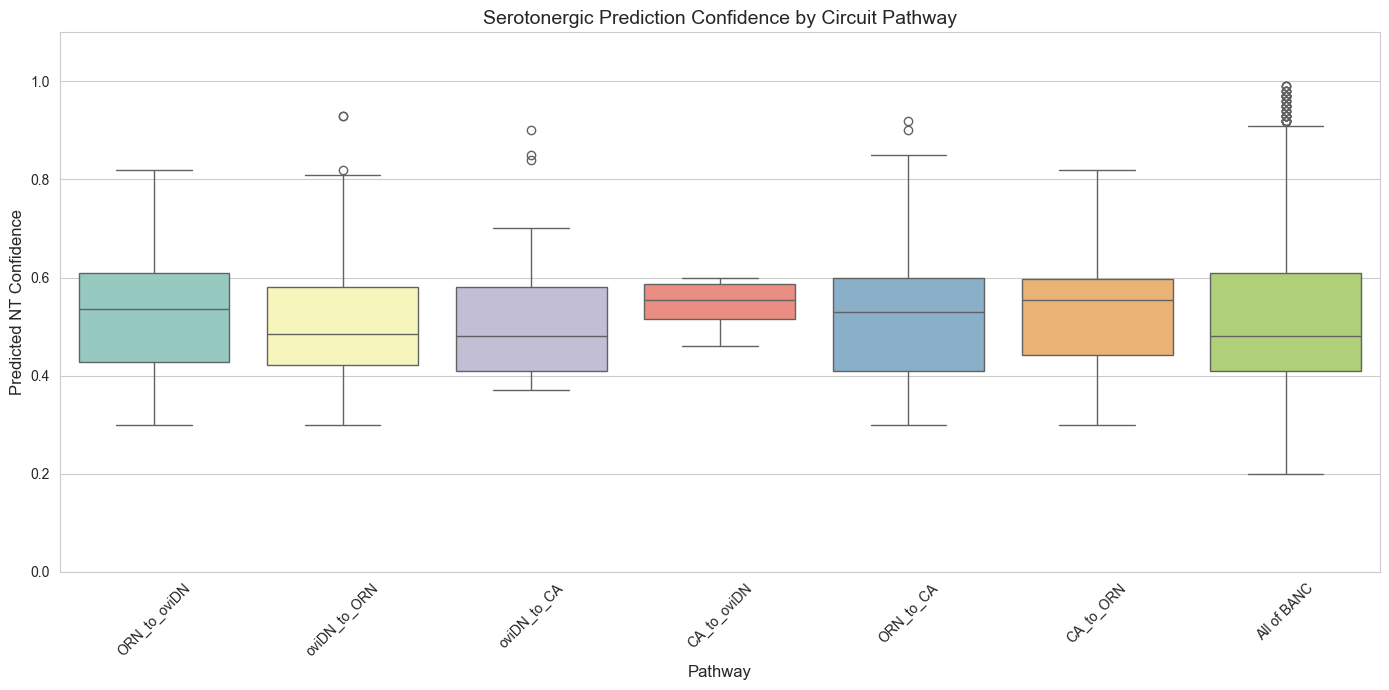

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load neuron attributes
neurons = pd.read_csv('data/neurons.csv')
serotonergic_neurons = neurons[neurons['Predicted NT type'] == 'SER']

# Total number of serotonergic neurons in the graph
total_serotonergic = len(serotonergic_neurons)

# Load the master edge list with direction information
# master_edge_list = pd.read_csv('/Users/ayushshrivastava/Downloads/ORN_CA_oviDN_COMPLETE_package/MASTER_pathway_edges_v2.csv')
master_edge_list = pd.read_csv('out/master_edge_list_with_direction.csv')  # Use the generated master edge list

# Define combinations of source and target groups
# combinations = [
#     (ORNs, oviDNs, 'ORN_to_OviDN'),
#     (oviDNs, ORNs, 'OviDN_to_ORN'),
#     (oviDNs, CAs, 'OviDN_to_CA'),
#     (CAs, oviDNs, 'CA_to_OviDN'),
#     (ORNs, CAs, 'ORN_to_CA'),
#     (CAs, ORNs, 'CA_to_ORN')
# ]

# Prepare data for plotting
plot_data = []

for source, target, label in combinations:
    # Get edges belonging to this specific circuit
    edges = master_edge_list[master_edge_list['direction'] == label]
    
    # Identify unique neurons (both pre and post) that appear in these circuits
    # Using .unique() ensures we don't double-count a neuron if it appears 
    # in multiple edges within the same circuit.
    path_neuron_ids = pd.concat([edges['pre_root_id'], edges['post_root_id']]).unique()
    
    # Filter neurons that are on these paths AND are predicted to be Serotonergic
    # We filter by ID first for efficiency, then by the NT type
    subset = neurons[neurons['Root ID'].isin(path_neuron_ids)]
    serotonergic_subset = subset[subset['Predicted NT type'] == 'SER']
    
    # Collect the confidence values and the circuit label for plotting
    for _, row in serotonergic_subset.iterrows():
        plot_data.append({
            'Circuit': label,
            'Confidence': row['Predicted NT confidence']
        })

# Connectome-wide
for _, row in serotonergic_neurons.iterrows():
    plot_data.append({
        'Circuit': 'All of BANC',
        'Confidence': row['Predicted NT confidence']
})

# Create a DataFrame for plotting
df_plot = pd.DataFrame(plot_data)

# Visualization: Boxplots of Confidence per Circuit
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.boxplot(x='Circuit', y='Confidence', data=df_plot, palette="Set3")

# Add a swarm plot on top to see individual points (optional but helpful for small N)
# sns.stripplot(x='Circuit', y='Confidence', data=df_plot, color='black', alpha=0.3, jitter=True)

plt.title('Serotonergic Prediction Confidence by Circuit Pathway', fontsize=14)
plt.ylabel('Predicted NT Confidence', fontsize=12)
plt.xlabel('Pathway', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, 1.1) # Since confidence is likely 0 to 1
plt.tight_layout()

# Save the plot if needed
# plt.savefig('serotonergic_confidence_distribution.png')
plt.show()

Determine the concentration of serotonin in each circuit, and determine if any circuits are more enriched for serotonin than the whole connectome.

In [7]:
from scipy.stats import hypergeom

neurons = pd.read_csv('data/neurons.csv')

# 1. Pre-calculate global variables and force them to standard Python ints
total_neurons = int(len(neurons))

def enrichment_analysis(nt_type):
    total_nt = int(len(neurons[neurons['Predicted NT type'] == nt_type]))

    # print(f"DEBUG: Total Neurons: {total_neurons}")
    # print(f"DEBUG: Total Serotonergic: {total_ser}")

    results = []
    for label in list(set(master_edge_list['direction'].unique())):
        # Get unique neurons for this circuit
        circuit_edges = master_edge_list[master_edge_list['direction'] == label]
        path_ids = set(circuit_edges['pre_root_id']) | set(circuit_edges['post_root_id'])
        n_total_in_circuit = int(len(path_ids))
        
        # Find how many of those are serotonergic
        # We specifically select the subset first to ensure we only look at valid neurons
        circuit_nt_indices = neurons[neurons['Root ID'].isin(path_ids)]
        n_nt_in_circuit = int(len(circuit_nt_indices[circuit_nt_indices['Predicted NT type'] == nt_type]))
        
        # CALCULATE P-VALUE ROBUSTLY
        if n_nt_in_circuit > 0:
            # sf(k, M, N, n) calculates the probability of seeing MORE than k successes.
            # To test if n_ser_in_circuit is significant, we want to know the 
            # probability of getting that many OR MORE.
            # Therefore, we pass (n_ser_in_circuit - 1) as the 'k' threshold.
            p_val = hypergeom.sf(n_nt_in_circuit - 1,
                                M=total_neurons,
                                n=total_nt,
                                N=n_total_in_circuit)
        else:
            # If there are no serotonergic neurons in the circuit, it's not "enriched"
            p_val = 1.0

        results.append({
            'Circuit': label,
            'Total Neurons': n_total_in_circuit,
            f'{nt_type}ergic Neurons': n_nt_in_circuit,
            'Concentration': n_nt_in_circuit / n_total_in_circuit if n_total_in_circuit > 0 else 0,
            'p-value': float(p_val) # Force to float to ensure no weird types remain
        })

    results.append({
        'Circuit': 'All of BANC',
        'Total Neurons': total_neurons,
        f'{nt_type}ergic Neurons': total_nt,
        'Concentration': total_nt / total_neurons if total_neurons > 0 else 0,
        'p-value': 1.0 # The whole graph is the baseline, so it's not "enriched" in itself
    })

    df_enrichment = pd.DataFrame(results)
    # print(df_enrichment)
    # print()

    significant = df_enrichment[df_enrichment['p-value'] < 0.0083]
    # print(f"The following pathways are significantly enriched for {nt_type} compared to the background, using a Bonferroni-corrected p-value of 0.00833:")
    print(df_enrichment)
    return significant[['Circuit', 'Concentration']]

significant = pd.DataFrame()  # Initialize an empty DataFrame to store significant results

for nt in neurons['Predicted NT type'].dropna().unique():
    s = enrichment_analysis(nt)
    s['NT'] = nt  # Add a column to indicate the NT type for each row
    significant = pd.concat([significant, s], ignore_index=True)
    print("===")
    print()

print(significant)

        Circuit  Total Neurons  ACHergic Neurons  Concentration       p-value
0  ORN_to_oviDN           3524              1835       0.520715  9.767849e-01
1     ORN_to_CA           2688              1437       0.534598  6.120266e-01
2   CA_to_oviDN            133                26       0.195489  1.000000e+00
3   oviDN_to_CA            618               179       0.289644  1.000000e+00
4  oviDN_to_ORN           1798              1039       0.577864  2.612941e-04
5     CA_to_ORN            667               568       0.851574  5.111017e-67
6   All of BANC         158262             85006       0.537122  1.000000e+00
===

        Circuit  Total Neurons  GABAergic Neurons  Concentration       p-value
0  ORN_to_oviDN           3524                493       0.139898  4.496152e-02
1     ORN_to_CA           2688                319       0.118676  9.667264e-01
2   CA_to_oviDN            133                 15       0.112782  7.612819e-01
3   oviDN_to_CA            618                106      

In [8]:
neurons.groupby('Predicted NT type')['Predicted NT confidence'].describe()

,count,mean,std,min,25%,50%,75%,max
Predicted NT type,,,,,,,,
ACH,85006.0,0.785316,0.169324,0.23,0.66,0.83,0.93,1.00
DA,8072.0,0.594877,0.142616,0.25,0.49,0.58,0.70,1.00
GABA,20604.0,0.808316,0.164294,0.21,0.71,0.85,0.95,1.00
GLUT,24382.0,0.733516,0.189444,0.22,0.58,0.76,0.91,1.00
HIST,7694.0,0.722039,0.199063,0.24,0.55,0.72,0.91,1.00
OCT,1903.0,0.476337,0.128848,0.23,0.39,0.46,0.53,0.98
SER,1612.0,0.523840,0.166020,0.20,0.41,0.48,0.61,0.99
TYR,209.0,0.609856,0.204179,0.31,0.44,0.54,0.83,0.97


## Visualizing enrichment analysis

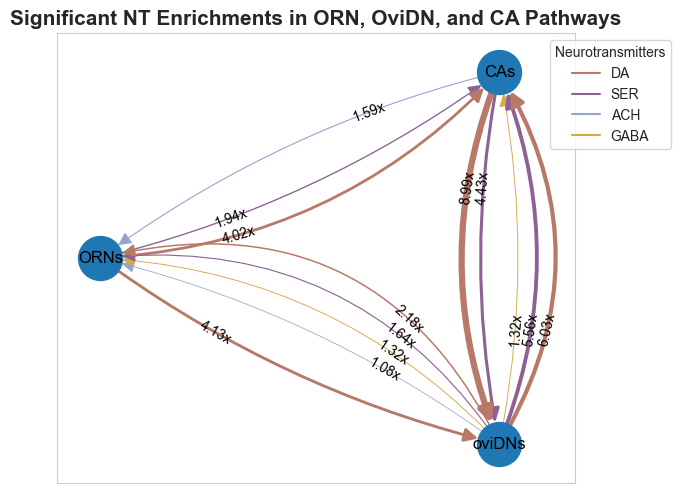

In [9]:
import itertools as it
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def draw(G, attr_name, ax=None):
    connection_style = [f"arc3,rad={r}" for r in it.accumulate([0.1] * G.number_of_edges())]
    pos = nx.shell_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1000)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=12)

    edge_colors = [attrs['color'] for *_, attrs in G.edges(data=True, keys=True)]
    widths = [attrs['width'] for *_, attrs in G.edges(data=True, keys=True)]

    nx.draw_networkx_edges(
        G, pos, edge_color=edge_colors, connectionstyle=connection_style, ax=ax, node_size=1000, arrowsize=20, width=widths
    )

    labels = {
        tuple(edge): attrs[attr_name] for *edge, attrs in G.edges(data=True, keys=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        labels,
        connectionstyle=connection_style,
        label_pos=0.3,
        font_color="black",
        bbox={"alpha": 0},
        ax=ax,
    )

fig = plt.figure()
G = nx.MultiDiGraph()
nodes = ["ORNs", "oviDNs", "CAs"]
G.add_nodes_from(nodes)

mapping = {
    "ORN_to_oviDN": ("ORNs", "oviDNs"),
    "oviDN_to_ORN": ("oviDNs", "ORNs"),
    "oviDN_to_CA": ("oviDNs", "CAs"),
    "CA_to_oviDN": ("CAs", "oviDNs"),
    "CA_to_ORN": ("CAs", "ORNs"),
    "ORN_to_CA": ("ORNs", "CAs")
}

colors = {
    "DA": "#B87969",
    "SER": "#8C6295",
    "ACH": "#95A3CE",
    "GABA": "#D5A848",
    "GLUT": "#86A859"
}

for _, row in significant.iterrows():
    circuit = row['Circuit']
    nt_type = row['NT']

    circuit_conc = row['Concentration']
    banc_conc = len(neurons[neurons['Predicted NT type'] == nt_type]) / len(neurons)
    enrichment_fold = circuit_conc / banc_conc if banc_conc > 0 else 1
    
    if circuit in mapping:
        source, target = mapping[circuit]
        G.add_edge(source, target, label=f"{enrichment_fold:.2f}x", color=colors[nt_type] if nt_type in colors else "gray", width=enrichment_fold / 2)

draw(G, 'label')

legend_elements = [Line2D([1], [0], color=color, label=nt_type) 
                    for nt_type, color in colors.items() 
                    if nt_type in significant['NT'].unique()]

ax = plt.gca()
ax.legend(handles=legend_elements, title="Neurotransmitters", loc='upper right', bbox_to_anchor=(1.2, 1))

fig.tight_layout()
plt.grid(False)
plt.title("Significant NT Enrichments in ORN, OviDN, and CA Pathways", fontsize=15, weight='bold')
plt.show()

## Comparison of output

Justin's method: all pathways where target is reachable within 5 hops.

My method: shortest paths only.

In [10]:
# import pandas as pd

# # Load your master edge list with direction information
# your_edge_list = pd.read_csv('out/master_edge_list_with_direction.csv')
# your_relevant_edges = your_edge_list[['direction', 'pre_root_id', 'post_root_id']]
# print("Total number of edges in your edge list:", len(your_relevant_edges))

# # Load your colleague's edge list
# colleague_edge_list = pd.read_csv('/Users/ayushshrivastava/Downloads/ORN_CA_oviDN_COMPLETE_package/MASTER_pathway_edges_v2.csv')
# colleague_relevant_edges = colleague_edge_list[['direction', 'pre_root_id', 'post_root_id']]
# print("Total number of edges in colleague's edge list:", len(colleague_relevant_edges))

# for _, _, c in combinations:
#     my_paths = your_edge_list[your_edge_list['direction'] == c]
#     colleague_paths = colleague_edge_list[colleague_edge_list['direction'] == c]

#     my_nodes = pd.concat([my_paths['pre_root_id'], my_paths['post_root_id']]).unique()
#     colleague_nodes  = pd.concat([colleague_paths['pre_root_id'], colleague_paths['post_root_id']]).unique()

#     print(f"Pathway: {c}| My subgraph: {len(my_nodes)} nodes, {len(my_paths)} edges | Justin's subgraph: {len(colleague_nodes)} nodes, {len(colleague_paths)} edges")


In [11]:
# oca = your_edge_list[your_edge_list['direction'] == 'CA_to_oviDN']
# pd.Series(pd.concat([oca['pre_root_id'], oca['post_root_id']]).unique()).to_clipboard(index=False)

In [12]:
# import pandas as pd

# confirmed_ovi = pd.read_csv("annotated_oviDN.csv")["Root ID"]
# confirmed_corpus_allatum = pd.read_csv("annotated_corpus_allatum.csv")["Root ID"]
# confirmed_yeasty_orn = pd.read_csv("annotated_yeasty_volatile.csv")["Root ID"]
# yeasty = pd.read_csv("data/yeast_orns.csv")["root_id"]
# others = pd.read_csv("data/given_neurons.csv")
# ovi = others[others['group'] == 'OviDN']['root_id']
# ca = others[others['group'] == 'CA']['root_id']

# print(confirmed_ovi[~confirmed_ovi.isin(ovi)])
# print(confirmed_corpus_allatum[~confirmed_corpus_allatum.isin(ca)])
# print(confirmed_yeasty_orn[~confirmed_yeasty_orn.isin(yeasty)])

# print(set(confirmed_ovi) == set(ovi))
# print(set(confirmed_corpus_allatum) == set(ca))
# print(set(confirmed_yeasty_orn) == set(yeasty))

## Sankeys

### OviDN -> CA

Identify unknown neurons

In [13]:
# import pandas as pd
# import networkx as nx

# edge_list = pd.read_csv('out/master_edge_list_with_direction.csv')
# edge_list = edge_list[edge_list['direction'] == 'oviDN_to_CA']
# graph = nx.from_pandas_edgelist(edge_list, source='pre_root_id', target='post_root_id', create_using=nx.DiGraph)

# given = pd.read_csv('data/given_neurons.csv')
# oviDNs = set(given[given['group'] == 'OviDN']['root_id'])
# CAs = set(given[given['group'] == 'CA']['root_id'])
# ORNs = set(given[given['group'] == 'ORN']['root_id'])

# unknowns = set(edge_list['pre_root_id']).union(set(edge_list['post_root_id'])) - oviDNs - CAs - ORNs
# print("All neurons:", len(set(edge_list['pre_root_id']).union(set(edge_list['post_root_id']))))
# print("Unknown neurons in the oviDN_to_CA pathway:", len(unknowns))

In [14]:
# """
# For a neuron to be an interneuron at layer N:
#     - It may have predecessors from any layers [0, N-1]
#     - Its successors must all be in layers [N+1, final_layer]
#     - Its successors must not include any neurons from layers [0, N] (or at least, no successors at layer N)
# """

# def bucket_by_hop(source: set, target: set, unknowns: set):
#     def get_clean_interneurons(predecessor_set: set, unknowns: set, G: nx.DiGraph):
#         interneurons = set()
#         for u in unknowns:
#             if u in predecessor_set: continue
#             is_clean_interneuron = True
#             for p in G.predecessors(u): # also check if u's successors are in the interneuron set?
#                 if p not in predecessor_set:
#                     is_clean_interneuron = False
#                     break
#             if is_clean_interneuron:
#                 interneurons.add(u)
#         return interneurons

#     final_hop = get_clean_interneurons(target, unknowns, graph.reverse(copy=False))

#     starting_set = source
#     counter = 1
#     unknown_to_hop = {}
#     print(f"Beginning with {len(starting_set)} neurons.")
#     print(f"Final hop has {len(final_hop)} neurons, plus 6 CAs")

#     while True:
#         next_hop = get_clean_interneurons(starting_set, unknowns, graph)
#         unknown_to_hop.update({u: counter for u in next_hop})
#         print(f"Visited {len(next_hop)} neurons at layer {counter}. Visited {len(starting_set)} neurons total.")
#         if next_hop.issubset(final_hop):
#             print("Reached final hop subset.")
#             break
#         starting_set = starting_set.union(next_hop)
#         if counter == 20:
#             diff = unknowns - starting_set
#             not_in_final = diff - final_hop
            
#             print(f"Failed to categorize {len(diff)} neurons")
#             print(f"{len(not_in_final)} were not in the final hop ({len(final_hop)} final hop neurons).")
#             print(f"{len(diff - oviDNs - CAs)} not in OviDNs or CAs")
#             raise Exception()
#         counter += 1

#     return unknown_to_hop, final_hop

# d, f = bucket_by_hop(oviDNs, CAs, unknowns)
# d = pd.DataFrame(list(d.items()), columns=['Root ID', 'Hop Count'])
# d.to_csv('unknowns_hop_count.csv', index=False)

# print(f"{len(d[d['Root ID'].isin(f)])} of {len(f)} neurons are clean interneurons.")
# clean_set = set(d['Root ID'])
# print(f"{len(unknowns - clean_set)} of {len(unknowns)} are NOT clean interneurons.")
# d.groupby('Hop Count').count()

# full_clean_circuit_set = clean_set.union(oviDNs, CAs)
# edge_list[(edge_list['pre_root_id'].isin(full_clean_circuit_set)) & (edge_list['post_root_id'].isin(full_clean_circuit_set))].to_csv("clean_sankey_edge_list.csv", index=False)

In [15]:
# import json
# import plotly.express as px
# # neurons_by_path_length = {}
# s = pd.Series(name='path_length')

# for ovi in oviDNs:
#     for ca in CAs:
#         paths = nx.algorithms.shortest_path_length(graph, ovi, ca)
#         s.loc[len(s)] = paths
#         # for path in paths:
#             # p = list(set(path) - oviDNs - CAs)
#             # if not neurons_by_path_length.get(len(path) - 1):
#             #     neurons_by_path_length[len(path) - 1] = []
#             # neurons_by_path_length[len(path) - 1].extend(p)

# # print(neurons_by_path_length)
# # with open("neurons_by_path_length.json", "w+") as f:
#     # json.dump(neurons_by_path_length, f)

# px.histogram(x=s).show()

In [16]:
# clean_edge_list = pd.read_csv('out/clean_sankey_edge_list.csv')
# attributes = pd.read_csv("neurons.csv")
# nt_map = attributes.set_index("Root ID")["Predicted NT type"].to_dict()

# def label_node(node_id):
#     if node_id in oviDNs:
#         return "OviDN"
#     if node_id in CAs:
#         return "CA"
#     hop = d[d['Root ID'] == node_id]['Hop Count'].values[0]
#     nt = nt_map.get(node_id, "Unknown")
#     return f"{hop}° {nt} interneuron"

# id_to_group = {n: label_node(n) for n in full_clean_circuit_set}

# print(id_to_group)

# def id_to_grp(i):
#     return id_to_group.get(i, "Other")

# clean_edge_list['pre_group'] = clean_edge_list['pre_root_id'].apply(id_to_grp)
# clean_edge_list['post_group'] = clean_edge_list['post_root_id'].apply(id_to_grp)

# clean_edge_list.groupby(['pre_group', 'post_group'])['syn_count'].sum().reset_index().to_csv("out/grouped_edge_list.csv", index=False)

In [17]:
# import plotly.graph_objects as go

# aggregated = pd.read_csv("out/grouped_edge_list.csv")

# # Build global labels
# name_to_idx = {}
# labels = []

# source = []
# target = []
# value = []

# for group in aggregated['pre_group'].unique():
#     if group not in name_to_idx:
#         name_to_idx[group] = len(labels)
#         labels.append(group)

# for group in aggregated['post_group'].unique():
#     if group not in name_to_idx:
#         name_to_idx[group] = len(labels)
#         labels.append(group)

# for _, row in aggregated.iterrows():
#     if row['pre_group'] == row['post_group']: 
#         print(f"{row['pre_group']} has {row['syn_count']} synapses onto itself.")
#         continue
#     source.append(name_to_idx[row['pre_group']])
#     target.append(name_to_idx[row['post_group']])
#     value.append(row['syn_count'])

# fig = go.Figure(data=[go.Sankey(
#     arrangement='snap',
#     node=dict(
#         pad=15,
#         thickness=20,
#         line=dict(color="black", width=0.5),
#         label=labels,
#     ),
#     link=dict(
#         arrowlen=15,
#         source=source,
#         target=target,
#         value=value,
#     ),
# )])

# fig.show()